# Robustness tests and bar plot

Goal having in one plot a visual comparaison between pure generated text and the paraphrased (Or modified) version. 

We compare the capabilities of our method between two steered LLMs with the ones of the traditional watermarking

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from matplotlib.patches import FancyBboxPatch


sys.path.append("../src")
import utils

In [4]:
plt.rcParams.update({
    # Figure size - ICML typically uses two-column format
    'figure.figsize': (3.25, 2.5),  # Single column width
    # 'figure.figsize': (6.75, 2.5),  # Double column width
    
    # Font sizes
    'font.size': 10,           # Base font size
    'axes.labelsize': 11,      # X and Y labels
    'axes.titlesize': 11,      # Title
    'xtick.labelsize': 9,      # X tick labels
    'ytick.labelsize': 9,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    
    # Font family
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Use LaTeX for text rendering (optional but recommended)
    'text.usetex': False,  # Set to True if you have LaTeX installed
    
    # Line widths
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Ticks
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.fancybox': False,
    'legend.edgecolor': 'black',
    
    # Save settings
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'savefig.format': 'pdf',  # PDF is preferred for publications
})



### 100 sentences, fresh news, Llama3.1-8B
=== Detection results summary individual ===
Vanilla detection results:
0.98
[0.69042581]
[0.30957419]
Watermarked detection results:
1.0
[0.9999999]
[9.81979829e-08]
Paraphrased detection results:
0.79
[0.97581944]
[0.02418056]

=== Detection results summary original ===
Confusion matrix:
 [[ 98   2]
 [  0 100]]
F1 score: 0.9900990099009901
Accuracy: 0.99

=== Detection results summary paraphrased ===
Confusion matrix:
 [[98  2]
 [21 79]]
F1 score: 0.8729281767955801
Accuracy: 0.885

- Chicken molly : llama3.1-8B, guardian, l=512, 250 sentences, 88min, wat_classification = 59|191 = 0.764, ogr_cl = 2|248=0.992

### 200 sentences, fresh news, llama3.1-8B

=== Detection results summary individual ===
Vanilla detection results:
0.93
[0.69812419]
[0.30187581]
Watermarked detection results:
1.0
[0.99999368]
[6.32413727e-06]
Paraphrased detection results:
0.715
[0.97936741]
[0.02063259]

Paraphrased vanilla detection results:
0.715
[0.97936741]
[0.02063259]
=== Detection results summary original ===
Confusion matrix:
 [[186  14]
 [  0 200]]
F1 score: 0.966183574879227
Accuracy: 0.965

=== Detection results summary paraphrased ===
Confusion matrix:
 [[186  14]
 [ 57 143]]
F1 score: 0.8011204481792717
Accuracy: 0.8225
=== Detection results summary paraphrased vanilla ===
Confusion matrix:
 [[  0   0]
 [114 286]]
F1 score: 0.8338192419825073
Accuracy: 0.715

- hip_civil: 200 sentences. paraphrasing Watermark + vanilla -> Slight fail


In [5]:
data = [
    # ["Llama3-8B", "ELI5", 0.8, 0.98, 0.70, 0.90, 0.99, 0.55, 0.99, 0.99],   # Dummy
    ["Llama3-8B", "Fresh news", 0.86, 0.98, 0.78, 0.93, 0.992, 0.764, 0, 0],
    # ["Ministral-8B", "ELI5", 0.8, 0.98, 0.70, 0.90, 0.99, 0.55, 0.99, 0.99],
    # ["Ministral-8B", "Fresh news", 0.8, 0.98, 0.70, 0.90, 0.99, 0.55, 0.99, 0.99],
    ["GTP-2", "Fresh news", 0.8, 0.98, 0.72, 0.92, 1.0, 0.72, 0, 0],        # Has not been tested with our method
]

### New protocole:

We have Human Vs Paraphrased(WT) in the main text and Paraphrased(Human) VS Paraphrased(WT) in appendix only.
Therefore we need two plots and two types of F1 scores

In [13]:
data = [
    # model_name, dataset_name, train_s, comp_type, tk_a, txta, tkpa, txpa, wt_a, wt_pa, txt_qual, par_qual 
    # glowing-kit_386bee23 for traditional watermark
    # katydid-bunny_dd4ad391 for our method
    ["Llama3.1-8B", "Fresh news", 1000, "hVSp(WT)", 0.9516, 1.0, 0.9476, 0.9975, 0.992, 0.6689, 0, 0],
    # many-vocal_12c18b28 ours
    ["Llama3.1-8B", "ELI5", 1000, "hVSp(WT)", 0.9442, 0.975, 0.7501, 0.83, 0.9302, 0.1681, 0, 0],

    # aardvark-pony_ec170b60
    ["Ministral3-8B", "Fresh news", 1000, "hVSp(WT)", 0.9727, 1.0, 0.9283, 0.995, 1.0, 0.5019, 0, 0],

    ["Ministral3-8B", "ELI5", 1000, "hVSp(WT)", 0.9487, 1.0, 0.6859, 0.6975, 1.0, 0.0198, 0, 0],


    # WITH HUMAN PARAPHRASED
    # ant-modest_d934db88
    ["Llama3.1-8B", "Fresh news", 1000, "p(h)VSp(WT)", 0.9522, 0.9925, 0.7637, 0.8575, 0.992, 0.6689, 0, 0],

    ["Llama3.1-8B", "ELI5", 1000, "p(h)VSp(WT)", 0.9442, 0.975, 0.723, 0.77, 0.9302, 0.1681, 0, 0],

    ["Ministral3-8B", "Fresh news", 1000, "p(h)VSp(WT)", 0.9742, 1.0, 0.8838, 0.9875, 1.0, 0.5019, 0, 0],

    ["Ministral3-8B", "ELI5", 1000, "p(h)VSp(WT)", 0.9486, 1.0, 0.6799, 0.6975, 1.0, 0.0198, 0, 0],
]

In [14]:
df = pd.DataFrame(
    data,
    columns=[
        "Model name",
        "Dataset name",

        "training_samples",
        "comparaison_type",

        "Token wise Accuracy",
        "Text wise Accuracy",

        "Paraphrased tokens Accuracy",
        "Paraphrased text Accuracy",

        "Traditional accuracy",
        "Paraphrased Traditional accuracy",

        "Text Quality",
        "Paraphrased Quality",
    ],
)


In [15]:
df = df[df["comparaison_type"] == "hVSp(WT)"]     # Filter only main text method
#p(h)VSp(WT)

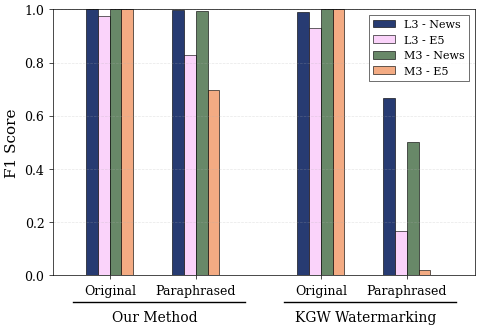

In [16]:
# Select the three metrics to compare
metrics = ["Text wise Accuracy", "Paraphrased text Accuracy",  "Traditional accuracy", "Paraphrased Traditional accuracy"]
metric_labels = ["Original", "Paraphrased", "Original", "Paraphrased"]

model_labels = {
    "Llama3.1-8B": "L3",
    "Ministral3-8B": "M3",
    "GTP-2": "G2",
}

dataset_labels = {
    "ELI5": "E5",
    "Fresh news": "News",
}

# colors = ['#2E86AB', '#A23B72', '#F18F01']  # Nice color scheme

# Get unique models and datasets
models = df["Model name"].unique()
datasets = df["Dataset name"].unique()

# Create combinations of model + dataset
combinations = []
combination_labels = []

for model in models:
    for dataset in datasets:
        row = df[(df["Model name"] == model) & (df["Dataset name"] == dataset)]
        if len(row) > 0:
            combinations.append((model, dataset))
            combination_labels.append(f"{model_labels.get(model, model)} - {dataset_labels.get(dataset, dataset)}")

# Prepare data: each metric is a group, each combination is a bar within that group
num_metrics = len(metrics)
num_combinations = len(combinations)

# Create color palette for different model-dataset combinations
# colors_palette = plt.cm.tab10(np.linspace(0, 1, num_combinations))
# colors_palette = [utils.batlow10_colors[i] for i in [1, 4, 6, 8]]
colors_palette = [utils.batlow_categorical_colors[i] for i in [0 , 1, 5,  4, 6]]
# colors_palette = [utils.batlow10_colors[i] for i in [0 , 7, 3, 9]]

# Set up positions
group_width = num_combinations * 0.3  # Increase this to make bars wider (was 0.8)
bar_width = 1.2 / num_combinations  # Increase this to make bars wider (was 0.8)
group_positions = np.arange(num_metrics) * (group_width + 0.1)  # Space between groups

# Define custom spacing between groups
gaps = [1.0, 2, 1.0]  # Small, Large, Small gaps
group_positions = [0]
for i, gap in enumerate(gaps):
    group_positions.append(group_positions[-1] + group_width + gap)
group_positions = np.array(group_positions)

# combinations_sorted = sorted(combinations, key=lambda x: (x[0], x[1]))


fig, ax = plt.subplots(figsize=(5.0, 3.5))

# Plot bars
for i, (model, dataset) in enumerate(combinations):
    row = df[(df["Model name"] == model) & (df["Dataset name"] == dataset)]
    
    # Get values for each metric
    values = [row[metric].values[0] for metric in metrics]
    
    # Calculate positions for this combination across all groups
    positions = group_positions + i * bar_width
    
    ax.bar(
        positions,
        values,
        bar_width,
        label=combination_labels[i],
        color=colors_palette[i],
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5,
    )

# Horizontal reference lines
# ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)
# ax.axhline(y=0.55, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)


# Customize the plot
# ax.set_xlabel('Accuracy Type')
ax.set_ylabel('F1 Score')
ax.set_xticks(group_positions + (num_combinations - 1) * bar_width / 2)
ax.set_xticklabels(metric_labels)
ax.legend(loc='best', ncol=1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.0)  # Assuming accuracy is between 0 and 1

# After setting up the main x-axis labels
ax.set_xticks(group_positions + (num_combinations - 1) * bar_width / 2)
ax.set_xticklabels(metric_labels)

# Add secondary x-axis labels for the pairs
# Calculate the center position of each pair
pair1_center = (group_positions[0] + group_positions[1]) / 2
pair2_center = (group_positions[2] + group_positions[3]) / 2

# Add text labels below the main axis
ax.text(pair1_center + 0.5, -0.13, 'Our Method', 
        ha='center', va='top',
        transform=ax.get_xaxis_transform())

ax.text(pair2_center + 0.5, -0.13, 'KGW Watermarking', 
        ha='center', va='top',
        transform=ax.get_xaxis_transform())
# Bracket for first pair
bracket1_x = group_positions[0] -0.5
bracket1_width = group_positions[1] - group_positions[0] + group_width + 1.0
ax.plot([bracket1_x, bracket1_x + bracket1_width], [-0.1, -0.1], 
        color='black', linewidth=1, transform=ax.get_xaxis_transform(), clip_on=False)

# Bracket for second pair
bracket2_x = group_positions[2] - 0.5
bracket2_width = group_positions[3] - group_positions[2] + group_width + 1.0
ax.plot([bracket2_x, bracket2_x + bracket2_width], [-0.1, -0.1], 
        color='black', linewidth=1, transform=ax.get_xaxis_transform(), clip_on=False)



plt.tight_layout()
plt.savefig('Robustness_bar_plot.pdf')
# plt.savefig('Robustness_bar_plot_double_paraphrased.pdf')
plt.show()
